# Cross-Subject Generalisation

Fit subject-specific connectivity models and evaluate their transfer to other subjects, alongside pooled leave-one-subject-out prediction.

Run this notebook from the project root. See the [project overview](README.md) for the full analysis workflow.


## Global Models and Cross-subject Generalisation

We then fitted global models for each subject independently using a single set of coefficients across all structural edges within one subject. Cross-subject generalisation was evaluated using MSE. For each train-test pair, the mdoel fitted on the training subject’s edges was applied to the test subject’s structural data. LOOCV across subjects was also performed.

In [1]:
from pathlib import Path
figure_dir = Path("figures/cross_subject_generalisation")
figure_dir.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.sparse.csgraph import shortest_path

base_path = "data/connectomes/"

def load_connectome(path):
    comments = []
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                comments.append(line.strip())
            else:
                break
    names = None
    for c in comments:
        if c.lower().startswith("# name:"):
            names = [x.strip() for x in c.split(":", 1)[1].split(",")]
    df = pd.read_csv(path, header=None, comment="#")
    if names is not None and len(names) == df.shape[0]:
        df.index = names
        df.columns = names
    return df

structural, functional = {}, {}
for pid in range(32, 51):
    structural[pid] = load_connectome(f"{base_path}{pid}_WFA_68.csv")
    functional[pid] = load_connectome(f"{base_path}{pid}_rsfMRI_68.csv")

subjects  = sorted(structural.keys())
n_regions = structural[subjects[0]].shape[0]
print(f"Loaded {len(subjects)} subjects, {n_regions} regions.")

Loaded 19 subjects, 68 regions.


In [2]:
def indirect_connectivity(S):
    n = S.shape[0]
    T = np.zeros_like(S)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            vals = [min(S[i, k], S[k, j]) for k in range(n)
                    if S[i, k] > 0 and S[k, j] > 0]
            if vals:
                T[i, j] = max(vals)
    return T

T_matrices = {}
for pid in subjects:
    S = structural[pid].values
    T_matrices[pid] = indirect_connectivity(S)
    print(f"  Subject {pid} done", end="\r")

print("Indirect connectivity computed for all subjects.")

Indirect connectivity computed for all subjects.


In [3]:
def get_edge_arrays(pid):
    """Return (s, t, f) 1-D arrays for all upper-triangle edges where s > 0."""
    S = structural[pid].values
    T = T_matrices[pid]
    F = functional[pid].values
    mask = np.triu(S > 0, k=1)
    return S[mask], T[mask], F[mask]

# Check edge counts
for pid in subjects[:3]:
    s, t, f = get_edge_arrays(pid)
    print(f"Subject {pid}: {len(s)} edges with s>0")

Subject 32: 886 edges with s>0
Subject 33: 884 edges with s>0
Subject 34: 927 edges with s>0


In [4]:
MODEL_SPECS = {
    1: {"label": "f ~ s",        "features": lambda s, t: np.column_stack([s])},
    2: {"label": "f ~ s + s²",   "features": lambda s, t: np.column_stack([s, s**2])},
    3: {"label": "f ~ t",        "features": lambda s, t: np.column_stack([t])},
    4: {"label": "f ~ t + t²",   "features": lambda s, t: np.column_stack([t, t**2])},
    5: {"label": "f ~ s + t",    "features": lambda s, t: np.column_stack([s, t])},
}

def fit_global_model(pid, model_id):
    s, t, f = get_edge_arrays(pid)
    X_raw = MODEL_SPECS[model_id]["features"](s, t)
    X = sm.add_constant(X_raw)
    result = sm.OLS(f, X).fit()
    return result

# Fit all models for all subjects
per_subject_models = {m: {} for m in MODEL_SPECS}
for pid in subjects:
    for m in MODEL_SPECS:
        per_subject_models[m][pid] = fit_global_model(pid, m)

# Summary: R² per subject per model
r2_df = pd.DataFrame(
    {MODEL_SPECS[m]["label"]: {pid: per_subject_models[m][pid].rsquared for pid in subjects}
     for m in MODEL_SPECS}
)
print("R² per subject per model:")
print(r2_df.round(4).to_string())
print(f"\nMean R²:")
print(r2_df.mean().round(4).to_string())

R² per subject per model:
     f ~ s  f ~ s + s²   f ~ t  f ~ t + t²  f ~ s + t
32  0.0824      0.0830  0.0119      0.0178     0.0858
33  0.0490      0.0491  0.0059      0.0072     0.0527
34  0.0557      0.0602  0.0084      0.0372     0.0576
35  0.0691      0.0713  0.0023      0.0028     0.0846
36  0.0564      0.0581  0.0013      0.0043     0.0626
37  0.0508      0.0518  0.0053      0.0089     0.0570
38  0.0571      0.0603  0.0041      0.0145     0.0590
39  0.0778      0.0810  0.0051      0.0095     0.0932
40  0.0861      0.0931  0.0118      0.0229     0.0922
41  0.0860      0.0949  0.0214      0.0461     0.0883
42  0.0544      0.0643  0.0094      0.0132     0.0546
43  0.0676      0.0684  0.0148      0.0208     0.0735
44  0.0542      0.0685  0.0062      0.0118     0.0612
45  0.0766      0.0797  0.0058      0.0299     0.0838
46  0.0588      0.0682  0.0072      0.0189     0.0612
47  0.0848      0.1043  0.0149      0.0240     0.0857
48  0.0425      0.0458  0.0009      0.0074     0.0569
49

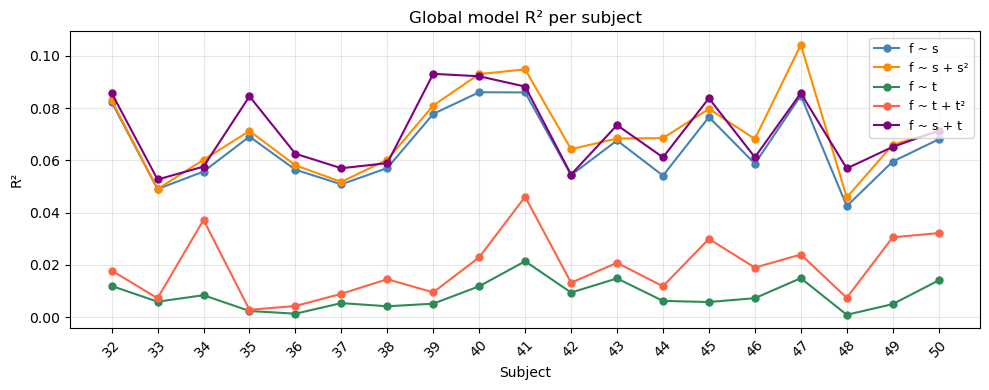

In [5]:
# Plot R² per subject for each model
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["steelblue", "darkorange", "seagreen", "tomato", "purple"]
for idx, m in enumerate(MODEL_SPECS):
    ax.plot(subjects, r2_df[MODEL_SPECS[m]["label"]], marker="o", label=MODEL_SPECS[m]["label"],
            color=colors[idx], linewidth=1.5, markersize=5)
ax.set_xlabel("Subject")
ax.set_ylabel("R²")
ax.set_title("Global model R² per subject")
ax.legend(fontsize=9)
ax.set_xticks(subjects)
ax.set_xticklabels(subjects, rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(figure_dir / 'r2_per_subject.png'), dpi=180, bbox_inches="tight")
plt.show()

In [6]:
def predict_and_mse(train_pid, test_pid, model_id):
    """Use train_pid's fitted model to predict test_pid's functional connectivity. Return MSE."""
    fitted = per_subject_models[model_id][train_pid]
    s_test, t_test, f_test = get_edge_arrays(test_pid)
    X_raw = MODEL_SPECS[model_id]["features"](s_test, t_test)
    X_test = sm.add_constant(X_raw, has_constant="add")
    f_pred = fitted.predict(X_test)
    return np.mean((f_test - f_pred) ** 2)

# Build full 19×19 cross-subject MSE matrix for each model
cross_mse = {}
for m in MODEL_SPECS:
    mat = np.zeros((len(subjects), len(subjects)))
    for i, train in enumerate(subjects):
        for j, test in enumerate(subjects):
            mat[i, j] = predict_and_mse(train, test, m)
    cross_mse[m] = mat

print("Cross-subject MSE matrices computed.")
print(f"\nModel 1 diagonal (within-subject train MSE), first 5 subjects:")
print(np.diag(cross_mse[1])[:5].round(6))
print(f"\nModel 1 off-diagonal mean (cross-subject MSE):")
off_diag = cross_mse[1][~np.eye(len(subjects), dtype=bool)]
print(off_diag.mean().round(6))

Cross-subject MSE matrices computed.

Model 1 diagonal (within-subject train MSE), first 5 subjects:
[0.00701  0.006564 0.006566 0.009006 0.005728]

Model 1 off-diagonal mean (cross-subject MSE):
0.006784


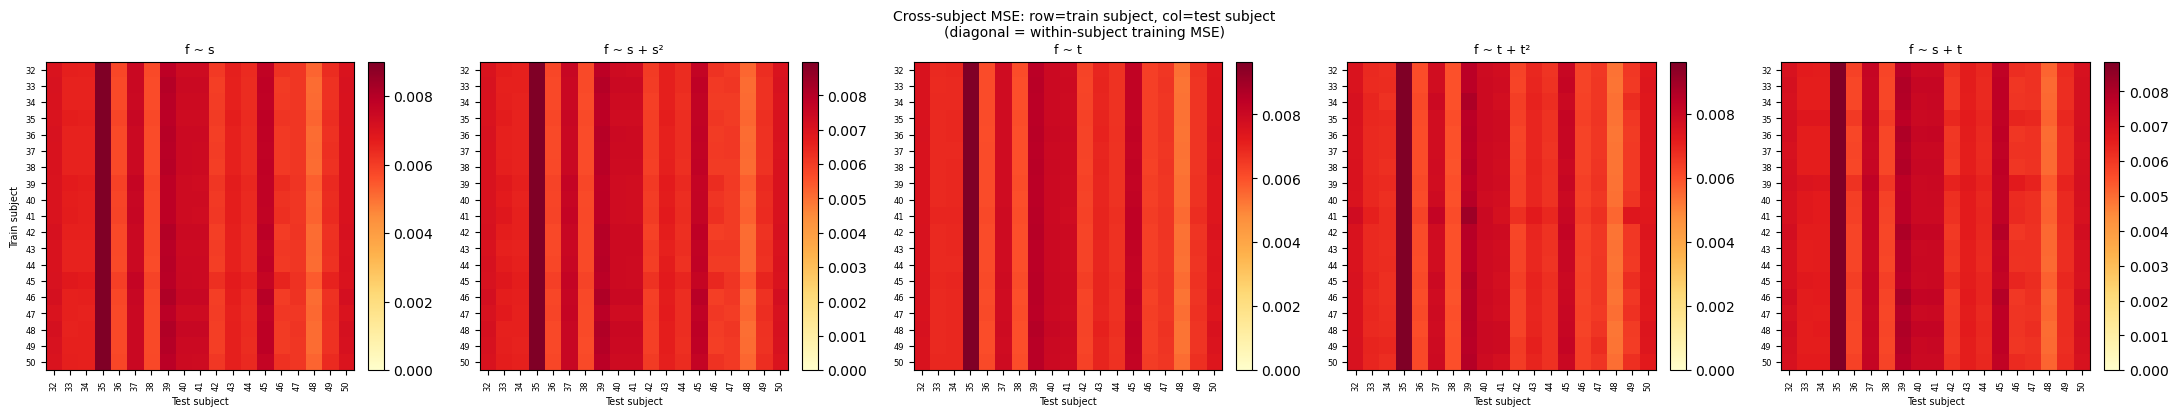

In [7]:
# Heatmaps of cross-subject MSE for all 5 models
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
subj_labels = [str(s) for s in subjects]

for idx, m in enumerate(MODEL_SPECS):
    mat = cross_mse[m]
    vmax = np.percentile(mat, 95)  # cap colorscale at 95th percentile
    im = axes[idx].imshow(mat, cmap="YlOrRd", vmin=0, vmax=vmax)
    axes[idx].set_title(MODEL_SPECS[m]["label"], fontsize=9)
    axes[idx].set_xticks(range(len(subjects)))
    axes[idx].set_yticks(range(len(subjects)))
    axes[idx].set_xticklabels(subj_labels, fontsize=6, rotation=90)
    axes[idx].set_yticklabels(subj_labels, fontsize=6)
    axes[idx].set_xlabel("Test subject", fontsize=7)
    if idx == 0:
        axes[idx].set_ylabel("Train subject", fontsize=7)
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

fig.suptitle("Cross-subject MSE: row=train subject, col=test subject\n(diagonal = within-subject training MSE)", fontsize=10)
plt.tight_layout()
plt.savefig(str(figure_dir / 'cross_subject_heatmap.png'), dpi=180, bbox_inches="tight")
plt.show()

     Model  Within-subject MSE (mean)  Within-subject MSE (std)  Cross-subject MSE (mean)  Cross-subject MSE (std)  Ratio (cross/within)
     f ~ s                   0.006713                  0.000905                  0.006784                 0.000912              1.010523
f ~ s + s²                   0.006676                  0.000911                  0.006758                 0.000913              1.012302
     f ~ t                   0.007130                  0.001013                  0.007164                 0.001011              1.004800
f ~ t + t²                   0.007052                  0.001007                  0.007142                 0.001020              1.012700
 f ~ s + t                   0.006670                  0.000882                  0.006762                 0.000889              1.013705


C:\Users\james\AppData\Local\Temp\ipykernel_21884\3659761476.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([diag, off], labels=["Within", "Cross"],
C:\Users\james\AppData\Local\Temp\ipykernel_21884\3659761476.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([diag, off], labels=["Within", "Cross"],
C:\Users\james\AppData\Local\Temp\ipykernel_21884\3659761476.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([diag, off], labels=["Within", "Cross"],
C:\Users\james\AppData\Local\Temp\ipykernel_21884\3659761476.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of box

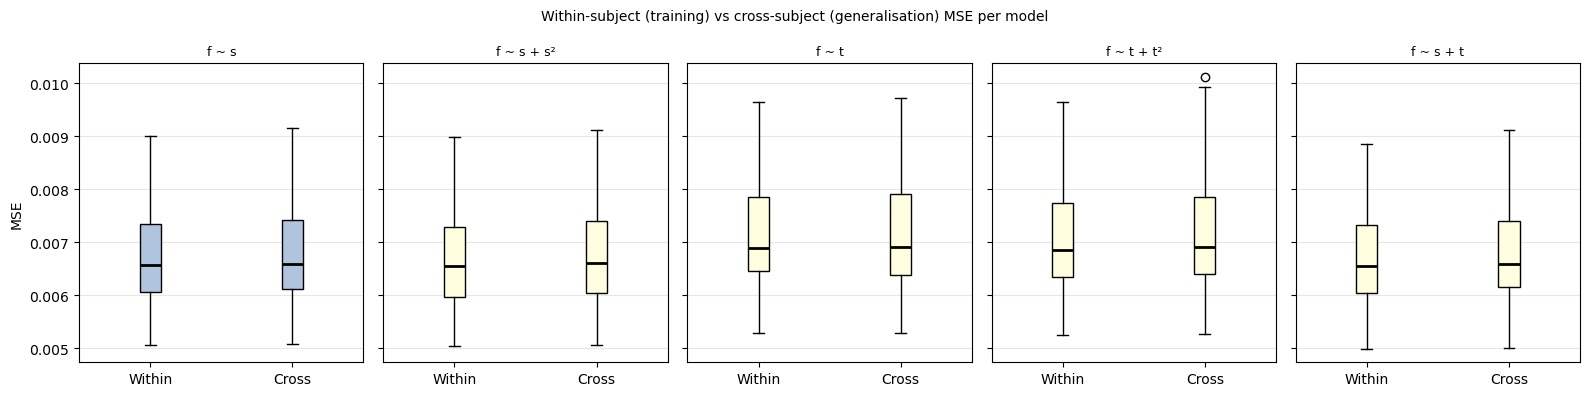

In [8]:
summary_rows = []
for m in MODEL_SPECS:
    mat = cross_mse[m]
    diag = np.diag(mat)
    off  = mat[~np.eye(len(subjects), dtype=bool)]
    summary_rows.append({
        "Model": MODEL_SPECS[m]["label"],
        "Within-subject MSE (mean)": diag.mean(),
        "Within-subject MSE (std)":  diag.std(),
        "Cross-subject MSE (mean)":  off.mean(),
        "Cross-subject MSE (std)":   off.std(),
        "Ratio (cross/within)":      off.mean() / diag.mean(),
    })

summary = pd.DataFrame(summary_rows)
print(summary.round(6).to_string(index=False))

# Boxplot: within vs cross for each model
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
colors_within = "steelblue"
colors_cross  = "tomato"

for idx, m in enumerate(MODEL_SPECS):
    mat  = cross_mse[m]
    diag = np.diag(mat)
    off  = mat[~np.eye(len(subjects), dtype=bool)]
    ax   = axes[idx]
    ax.boxplot([diag, off], labels=["Within", "Cross"],
               patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue" if idx == 0 else "lightyellow"),
               medianprops=dict(color="black", linewidth=2))
    ax.set_title(MODEL_SPECS[m]["label"], fontsize=9)
    ax.set_ylabel("MSE" if idx == 0 else "")
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Within-subject (training) vs cross-subject (generalisation) MSE per model", fontsize=10)
plt.tight_layout()
plt.savefig(str(figure_dir / 'within_vs_cross_mse.png'), dpi=180, bbox_inches="tight")
plt.show()

In [9]:
def loocv_subjects(model_id):
    """LOOCV across subjects: train on 18, predict the left-out subject."""
    mse_list = []
    for test_pid in subjects:
        train_pids = [p for p in subjects if p != test_pid]

        # Pool all edges from training subjects
        s_all = np.concatenate([get_edge_arrays(p)[0] for p in train_pids])
        t_all = np.concatenate([get_edge_arrays(p)[1] for p in train_pids])
        f_all = np.concatenate([get_edge_arrays(p)[2] for p in train_pids])

        X_raw = MODEL_SPECS[model_id]["features"](s_all, t_all)
        X     = sm.add_constant(X_raw)
        model = sm.OLS(f_all, X).fit()

        # Predict test subject
        s_test, t_test, f_test = get_edge_arrays(test_pid)
        X_test = sm.add_constant(
            MODEL_SPECS[model_id]["features"](s_test, t_test), has_constant="add"
        )
        f_pred = model.predict(X_test)
        mse_list.append(np.mean((f_test - f_pred) ** 2))

    return mse_list

loocv_mse = {}
for m in MODEL_SPECS:
    loocv_mse[m] = loocv_subjects(m)
    print(f"Model {m} LOOCV done, mean MSE = {np.mean(loocv_mse[m]):.6f}")

# Summary table
loocv_df = pd.DataFrame(
    {MODEL_SPECS[m]["label"]: loocv_mse[m] for m in MODEL_SPECS},
    index=subjects
)
print("\nLOOCV MSE per subject:")
print(loocv_df.round(6).to_string())
print("\nMean LOOCV MSE per model:")
print(loocv_df.mean().round(6).to_string())

Model 1 LOOCV done, mean MSE = 0.006749
Model 2 LOOCV done, mean MSE = 0.006718
Model 3 LOOCV done, mean MSE = 0.007147
Model 4 LOOCV done, mean MSE = 0.007093


Model 5 LOOCV done, mean MSE = 0.006717

LOOCV MSE per subject:
       f ~ s  f ~ s + s²     f ~ t  f ~ t + t²  f ~ s + t
32  0.007034    0.007034  0.007556    0.007507   0.007006
33  0.006584    0.006623  0.006867    0.006868   0.006560
34  0.006568    0.006535  0.006896    0.006758   0.006562
35  0.009044    0.009005  0.009659    0.009710   0.008954
36  0.005741    0.005732  0.006082    0.006060   0.005720
37  0.007490    0.007497  0.007847    0.007831   0.007442
38  0.005695    0.005675  0.006019    0.005963   0.005694
39  0.007926    0.007900  0.008481    0.008485   0.007862
40  0.007408    0.007350  0.007974    0.007899   0.007373
41  0.007401    0.007344  0.007917    0.007807   0.007390
42  0.005995    0.005932  0.006271    0.006273   0.006035
43  0.006593    0.006608  0.006968    0.006930   0.006553
44  0.006346    0.006269  0.006662    0.006632   0.006299
45  0.007761    0.007712  0.008264    0.008076   0.007659
46  0.006104    0.006050  0.006348    0.006276   0.006103
47  0.00

**Table 5:** Global model performance. Mean $R^2$ across 19 subjects; LOOCV MSE from 18-subject pooled training with single subject held out.

| Model | Mean $R^2$ | LOOCV MSE (mean) | LOOCV MSE (min) |
| --- | --- | --- | --- |
| $f_{ij}=\alpha+\beta s_{ij}+\gamma t_{ij}$ | 0.071 | 0.006717 | 0.005056 (subj. 48) |
| $f_{ij}=\alpha+\beta s_{ij}+\gamma s_{ij}^2$ | 0.071 | 0.006718 | 0.005110 (subj. 48) |
| $f_{ij}=\alpha+\beta s_{ij}$ | 0.065 | 0.006749 | 0.005126 (subj. 48) |
| $f_{ij}=\alpha+\beta t_{ij}+\gamma t_{ij}^2$ | 0.019 | 0.007093 | 0.005300 (subj. 48) |
| $f_{ij}=\alpha+\beta t_{ij}$ | 0.008 | 0.007147 | 0.005346 (subj. 48) |

## Global Model Performance

Global linear regression explains only 6.5-7.1% of the variance in fuctional connectivity, much less than expected. The combined model $f_{ij}=\alpha+\beta,s_{ij}+\gamma,t_{ij}$ barely achieves the lowest LOOCV MSE, which is consistent with the per-edge findings showing that indirect connectivity adds some marginal predictive value.

C:\Users\james\AppData\Local\Temp\ipykernel_21884\766199709.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


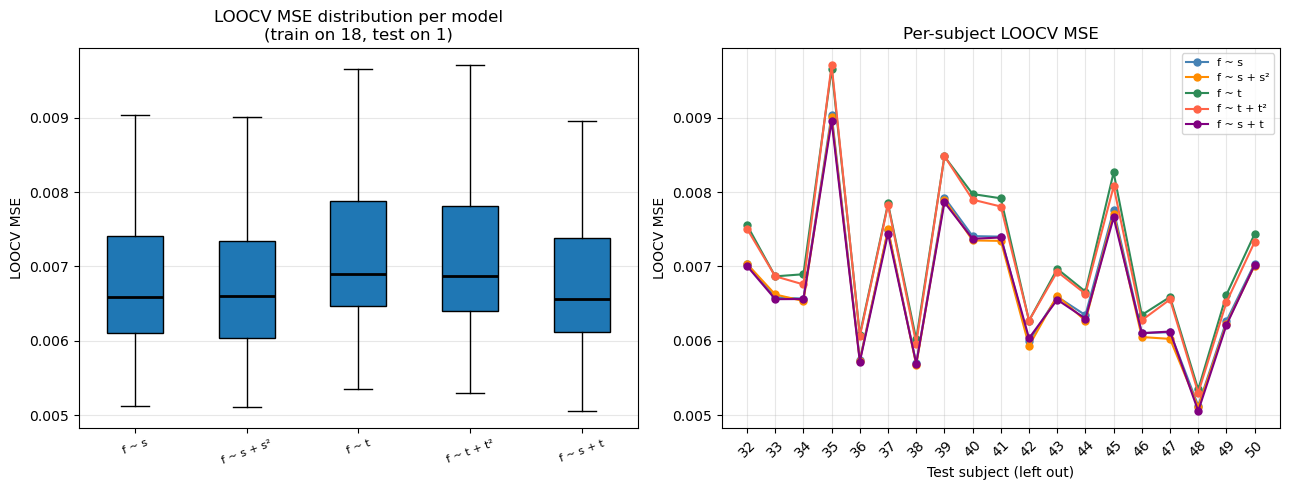

In [10]:
# Final comparison plot: LOOCV MSE per model (boxplot) + per-subject line
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: boxplot of LOOCV MSE across subjects per model
loocv_long = loocv_df.melt(var_name="Model", value_name="LOOCV MSE")
axes[0].boxplot(
    [loocv_df[col].values for col in loocv_df.columns],
    labels=loocv_df.columns,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)
axes[0].set_ylabel("LOOCV MSE")
axes[0].set_title("LOOCV MSE distribution per model\n(train on 18, test on 1)")
axes[0].set_xticklabels(loocv_df.columns, rotation=20, fontsize=8)
axes[0].grid(alpha=0.3, axis="y")

# Right: per-subject LOOCV MSE for all models
for idx, m in enumerate(MODEL_SPECS):
    axes[1].plot(subjects, loocv_mse[m], marker="o", label=MODEL_SPECS[m]["label"],
                 color=colors[idx], linewidth=1.5, markersize=5)
axes[1].set_xlabel("Test subject (left out)")
axes[1].set_ylabel("LOOCV MSE")
axes[1].set_title("Per-subject LOOCV MSE")
axes[1].legend(fontsize=8)
axes[1].set_xticks(subjects)
axes[1].set_xticklabels(subjects, rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(figure_dir / 'loocv_subject.png'), dpi=180, bbox_inches="tight")
plt.show()

## Cross-subject Generalisation

For model 1 ($f_{ij}=\alpha+\beta,s_{ij}$), the mean training MSE is 0.006713 and the mean cross-subject MSE is 0.006784 (1:1.011). This ratio indicates excellent generalisation, and that The structural-functional relationship learned from one subject transfers well to an unseen subject, implying that the linear structural constraint on functional connectivity is consistent across individuals. Across five models, the MSE ratios (within vs cross subject MSE) ranges from 1.005 to 1.014, confirming that generalisation is good. Subject 35 shows the highest LOOCV MSE (0.008954–0.009710) across all five models, which suggests an abnormal structural-functional relationship.

**Verification note:** The 6.5–7.1% range applies to the models including direct connectivity; the indirect-only models explain approximately 0.8–1.9%. Similar training and cross-subject errors indicate limited deterioration on transfer, but do not by themselves establish strong predictive accuracy. Subject 35’s higher error does not establish a biological or clinical abnormality.